## 3_1 Training using SVM Linear

In [13]:
import pandas as pd
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix , PrecisionRecallDisplay ,balanced_accuracy_score, matthews_corrcoef
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, KFold
import numpy as np
from sklearn.model_selection import RandomizedSearchCV , learning_curve
from scipy.stats import uniform
from sklearn.utils import resample
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('ds/Fraud_cleaned_dataset.csv' , nrows=300000 )
data.head(1)

,Unnamed: 0,category,amt,gender,lat,long,city_pop,job,merch_lat,merch_long,is_fraud,trans_hour,trans_month,trans_day,trans_year,age
0,0,8,-0.407826,0,-0.48442,0.65762,-0.282589,370,-0.494354,0.593864,0,-1.878145,-1.504564,-1.652258,-0.634065,-0.890761


In [3]:

# target
y = data['is_fraud']

# features rest columns
X = data.drop(columns=['is_fraud'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [4]:
#search best parameters

#it takes too much time to check all the parameters we choose just C the most importan
#and also class weight should be balnced because we have imbalance in clases
param_distributions = {
    'C': uniform(0.1, 100),
}

#penalty{‘l1’, ‘l2’} , loss{‘hinge’, ‘squared_hinge’} , dual , C regulirastion
random_search = RandomizedSearchCV(
    estimator = LinearSVC(dual=False, max_iter=5000, random_state=42 , class_weight='balanced'),
    param_distributions=param_distributions,
    n_iter=10,
    cv=5 , # 5k validation fold
    scoring='balanced_accuracy', # to check  2 class equaly we have imbalance
    random_state=42,
    n_jobs=-1 
)

random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LinearSVC(cla...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.",{'C': <scipy.stats....0023130935550>}
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",

In [5]:
#params found by random search
print(f"parameters : {random_search.best_params_}")
print(f" balanced_accuracy : {random_search.best_score_:.4f}")

#c 5.9 , balanced_accuracy 0.85

parameters : {'C': np.float64(86.7176145774935)}
 balanced_accuracy : 0.8354


In [6]:

#svm model linear 
svm_model = LinearSVC(random_state=42 , C=86 , class_weight='balanced' , dual=False, max_iter=10000)

svm_model.fit(X_train, y_train)

#prediction
y_pred = svm_model.predict(X_test)

#we need this to analyse under and over fitting
y_pred_train = svm_model.predict(X_train)


In [7]:
# simple evaluation
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97     59549
           1       0.11      0.76      0.19       451

    accuracy                           0.95     60000
   macro avg       0.55      0.86      0.58     60000
weighted avg       0.99      0.95      0.97     60000



In [8]:
#validation croise k fold 10 splits

kf = KFold(n_splits=10, shuffle=True, random_state=42)

scores = cross_val_score(svm_model, X, y, cv=kf, scoring='precision_macro')

print('based on precision_macro (average of both class ) ')
print(f"cross validation 10 Parts : {scores}")
print(f" Average: {np.mean(scores):.2f}")

based on precision_macro (average of both class ) 
cross validation 10 Parts : [0.55349123 0.55297657 0.55613474 0.55111777 0.5516907  0.55771485
 0.55498434 0.54798914 0.55848888 0.57219192]
 Average: 0.56


In [9]:
#confusion matric
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f" TP: {tp} , TN: {tn} , FP: {fp} , FN: {fn} , ")

 TP: 343 , TN: 56743 , FP: 2806 , FN: 108 , 


In [10]:
#metrics avancee

metrics_av = {
    "MCC": {
        "Train": matthews_corrcoef(y_train, y_pred_train),
        "Test": matthews_corrcoef(y_test, y_pred)
    },
    "Balanced_Accuracy": {
        "Train": balanced_accuracy_score(y_train, y_pred_train),
        "Test": balanced_accuracy_score(y_test, y_pred)
    }
}


print("mcc score learning : " , metrics_av["MCC"]["Train"])
print("mcc score test : " , metrics_av["MCC"]["Test"])
print()
print("Balnced Accuracy learning : " , metrics_av["Balanced_Accuracy"]["Train"])
print("Balnced Accuracy   test : " , metrics_av["Balanced_Accuracy"]["Test"])

mcc score learning :  0.2648758200278411
mcc score test :  0.2763185888128618

Balnced Accuracy learning :  0.8373440406583127
Balnced Accuracy   test :  0.8567056461616751


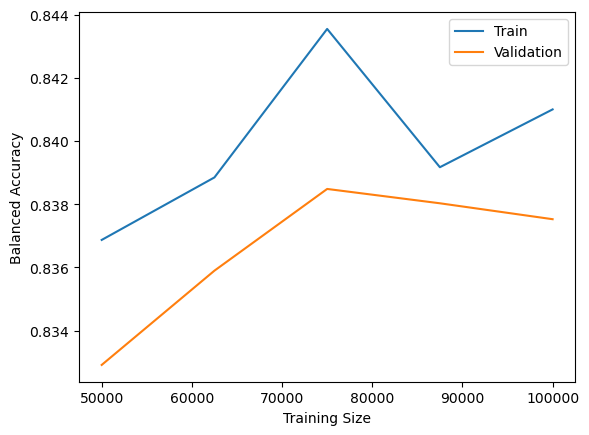

In [15]:
X_sample, y_sample = resample(X, y, n_samples=150_000, stratify=y, random_state=42)

train_sizes, train_scores, test_scores = learning_curve(
    svm_model, X_sample, y_sample, cv=3, scoring='balanced_accuracy',
     train_sizes=np.linspace(0.5, 1.0, 5),
    error_score=np.nan
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label='Train')
plt.plot(train_sizes, test_mean, label='Validation')
plt.xlabel('Training Size')
plt.ylabel('Balanced Accuracy')
plt.legend()
plt.show()

#no need for learning curve precision of class 1 is very low

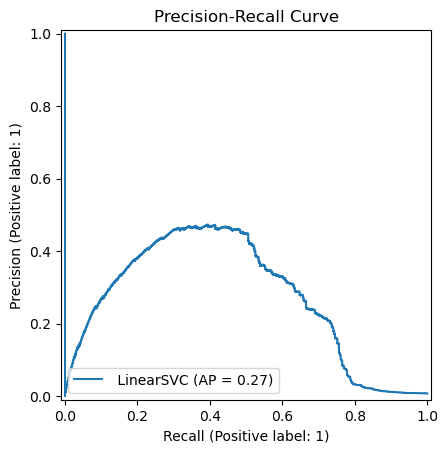

In [16]:
display = PrecisionRecallDisplay.from_estimator(
    random_search.best_estimator_, X_test, y_test, name=" LinearSVC"
)
plt.title("Precision-Recall Curve")
plt.show()

In [22]:
import joblib

# Save the model
joblib.dump(svm_model, 'parameters/linear_svm_fraud_model.pkl')


['parameters/linear_svm_fraud_model.pkl']